# Amazon Sales Dataset Analysis: Consumer Insights & Strategy Optimization

## 1. Introduction
This comprehensive analysis examines Amazon marketplace data to identify key drivers of product success. By evaluating pricing, discounting, customer sentiment, and category performance, we aim to provide data-driven strategies for product optimization and marketing.

## 2. Objectives
1. **Consumer Choice Analysis:** Explore categories, pricing thresholds, and discounts to uncover conversion drivers.
2. **Product Development & Strategy:** Identify high-performing features to suggest actionable product improvements.
3. **Sentiment & Communication Strategy:** Analyze textual reviews to shape targeted marketing copy.

## 3. Libraries and Setup
We utilize `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for professional visualizations, and `nltk`'s VADER for sentiment analysis of customer reviews.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Set plotting style for clean and professional visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Download VADER lexicon for sentiment classification
nltk.download('vader_lexicon')

print("Setup complete! Libraries imported and VADER lexicon downloaded successfully.")

Setup complete! Libraries imported and VADER lexicon downloaded successfully.


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
from google.colab import files
import io

print("Please select and upload your 'amazon.csv' file:")
uploaded = files.upload()

# Load data into a Pandas DataFrame
df = pd.read_csv(io.BytesIO(uploaded['amazon.csv']))
print(f"\nDataset loaded successfully! Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Please select and upload your 'amazon.csv' file:


Saving amazon.csv to amazon.csv

Dataset loaded successfully! Rows: 1465, Columns: 16


In [ ]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,0.64,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,0.43,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,0.90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,0.53,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,0.61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [ ]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000
mean,3125.310874,5444.990635,0.476915,4.096587,18277.634812
std,6944.304394,10874.826864,0.216359,0.291574,42727.398216
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,0.320000,4.000000,1191.000000
50%,799.000000,1650.000000,0.500000,4.100000,5179.000000
75%,1999.000000,4295.000000,0.630000,4.300000,17325.000000
max,77990.000000,139900.000000,0.940000,5.000000,426973.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1465 non-null   float64
 7   rating_count         1465 non-null   float64
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

In [ ]:
# 1. Clean price variables (Remove currency symbol '₹' and comma separators)
df['discounted_price'] = df['discounted_price'].astype(str).str.replace('₹', '').str.replace(',', '').astype(float)
df['actual_price'] = df['actual_price'].astype(str).str.replace('₹', '').str.replace(',', '').astype(float)

# 2. Clean discount percentage (Convert text '64%' to float 0.64)
df['discount_percentage'] = df['discount_percentage'].astype(str).str.replace('%', '').astype(float) / 100.0

# 3. Clean product ratings (Handle invalid anomalies like '|' and fill missing values)
df['rating'] = df['rating'].replace('|', np.nan).astype(float)
df['rating'] = df['rating'].fillna(df['rating'].median())

# 4. Clean rating count (Remove commas and treat missing entries)
df['rating_count'] = df['rating_count'].astype(str).str.replace(',', '').astype(float)
df['rating_count'] = df['rating_count'].fillna(df['rating_count'].median())

print("Data Cleaning Complete. Missing values resolved and numeric variables converted.")
df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].dropna().describe()

Data Cleaning Complete. Missing values resolved and numeric variables converted.


,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000
mean,3125.310874,5444.990635,0.476915,4.096587,18277.634812
std,6944.304394,10874.826864,0.216359,0.291574,42727.398216
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,0.320000,4.000000,1191.000000
50%,799.000000,1650.000000,0.500000,4.100000,5179.000000
75%,1999.000000,4295.000000,0.630000,4.300000,17325.000000
max,77990.000000,139900.000000,0.940000,5.000000,426973.000000


In [ ]:
# Extract high-level Category and Sub-category groups from the piped string structure
df['main_category'] = df['category'].apply(lambda x: str(x).split('|')[0] if pd.notna(x) else 'Unknown')
df['sub_category'] = df['category'].apply(lambda x: str(x).split('|')[1] if pd.notna(x) and len(str(x).split('|')) > 1 else 'Other')

# Proxy calculation for Estimated Popularity/Volume Index based on ratings count
df['popularity_index'] = df['rating_count']

# Estimated Gross Value indicator (Price * Volume proxy)
df['estimated_revenue_metric'] = df['discounted_price'] * df['rating_count']

print("Engineered Features: 'main_category', 'sub_category', 'popularity_index', and 'estimated_revenue_metric'.")

Engineered Features: 'main_category', 'sub_category', 'popularity_index', and 'estimated_revenue_metric'.


/tmp/ipykernel_10331/538455748.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_10331/538455748.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


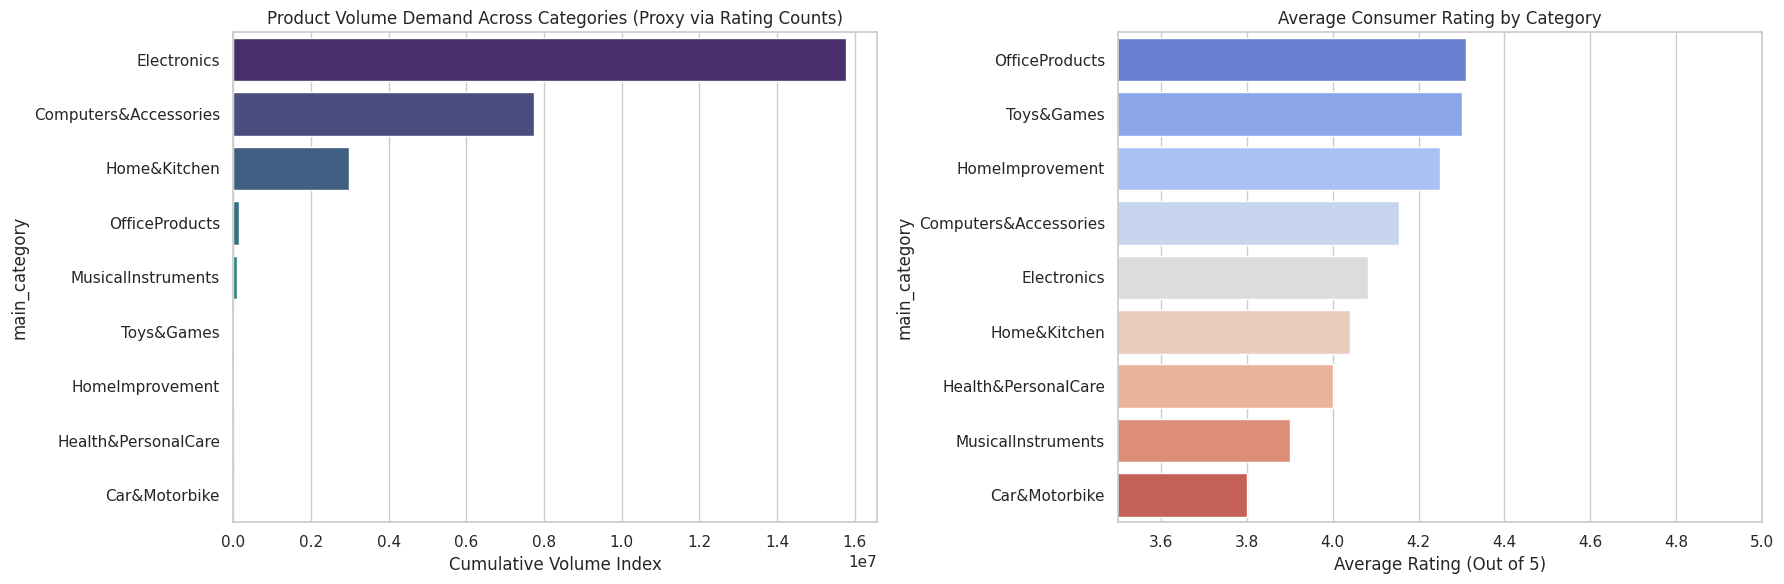

In [ ]:
# Visualize volume and rating traits across different product segments
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot A: Top Main Categories by Demand (Popularity Volume)
sns.barplot(
    data=df.groupby('main_category')['popularity_index'].sum().reset_index().sort_values(by='popularity_index', ascending=False),
    x='popularity_index', y='main_category', palette='viridis', ax=axes[0]
)
axes[0].set_title('Product Volume Demand Across Categories (Proxy via Rating Counts)')
axes[0].set_xlabel('Cumulative Volume Index')

# Subplot B: Average Customer Satisfaction by Category
sns.barplot(
    data=df.groupby('main_category')['rating'].mean().reset_index().sort_values(by='rating', ascending=False),
    x='rating', y='main_category', palette='coolwarm', ax=axes[1]
)
axes[1].set_title('Average Consumer Rating by Category')
axes[1].set_xlabel('Average Rating (Out of 5)')
axes[1].set_xlim(3.5, 5.0)

plt.tight_layout()
plt.show()

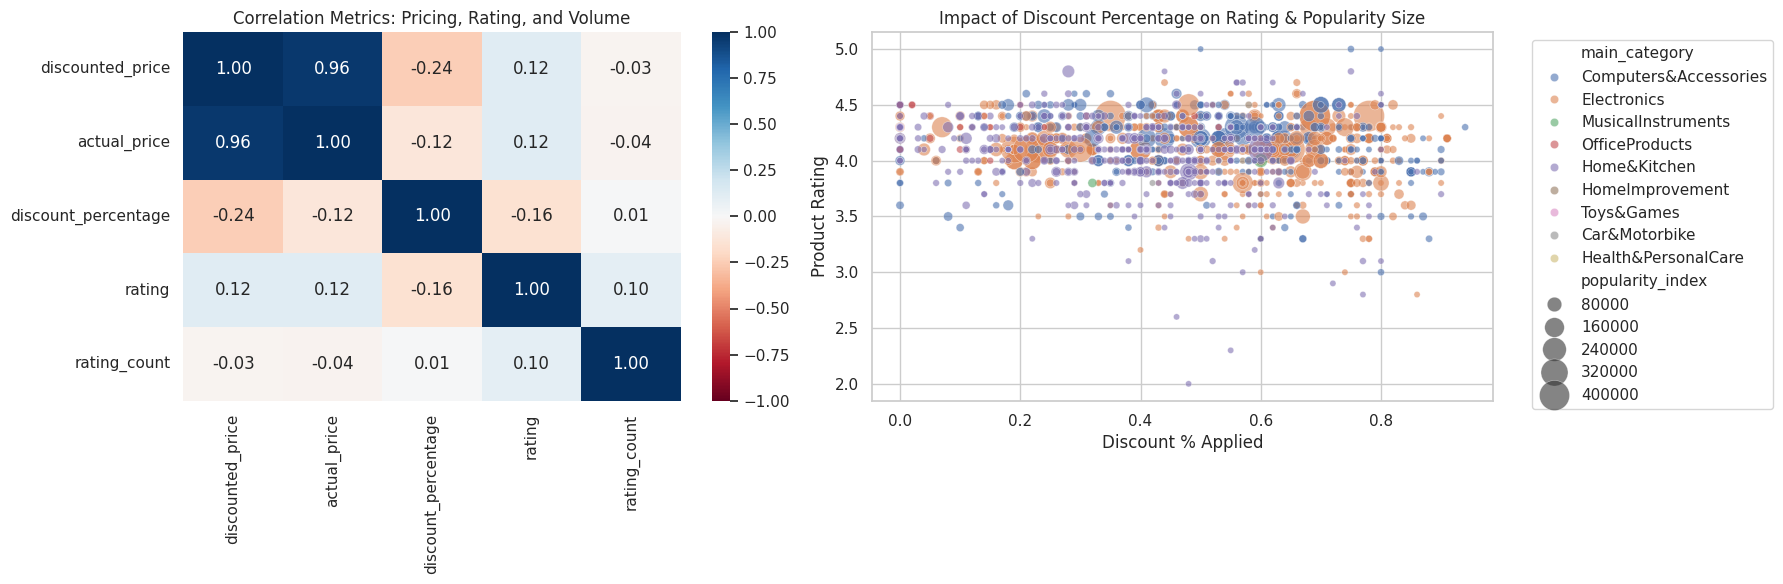

In [ ]:
# Analyze relationship patterns between Pricing, Discounting and Demand Volume
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot A: Correlation Matrix
corr_matrix = df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation Metrics: Pricing, Rating, and Volume')

# Subplot B: Discount Strategy Scatter Relationship
sns.scatterplot(
    data=df, x='discount_percentage', y='rating',
    size='popularity_index', hue='main_category', alpha=0.6, sizes=(20, 500), ax=axes[1]
)
axes[1].set_title('Impact of Discount Percentage on Rating & Popularity Size')
axes[1].set_xlabel('Discount % Applied')
axes[1].set_ylabel('Product Rating')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

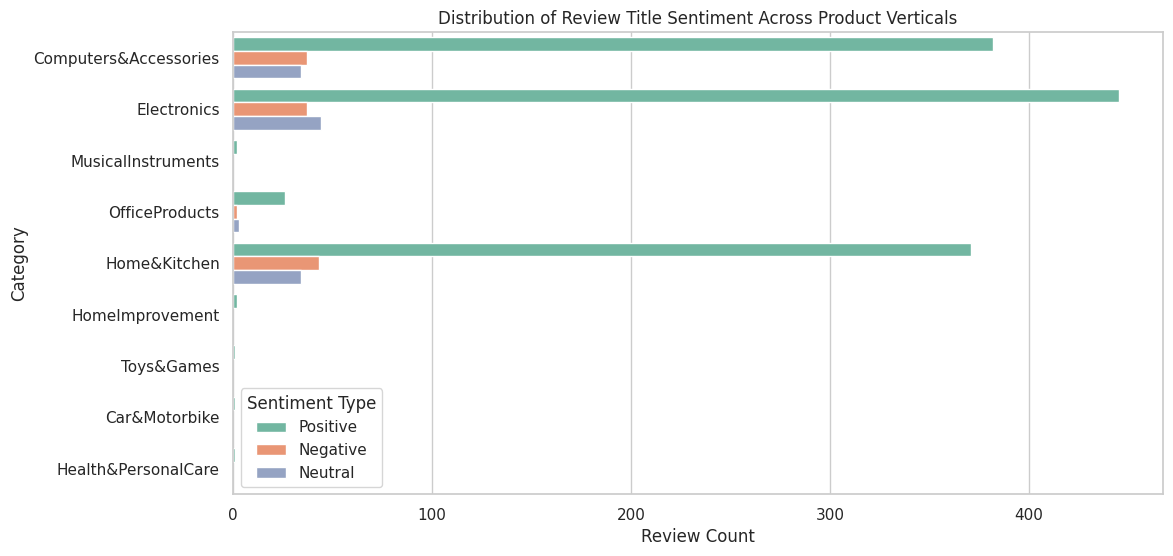

In [ ]:
# Calculate Sentiment Scores for product evaluation reviews
sia = SentimentIntensityAnalyzer()
df['sentiment_score'] = df['review_title'].fillna('').apply(lambda x: sia.polarity_scores(x)['compound'])

# Categorize general textual expression responses
def evaluate_sentiment_label(score):
    if score >= 0.05: return 'Positive'
    elif score <= -0.05: return 'Negative'
    return 'Neutral'

df['sentiment_category'] = df['sentiment_score'].apply(evaluate_sentiment_label)

# Plot customer review distribution across categories
sns.countplot(data=df, y='main_category', hue='sentiment_category', palette='Set2')
plt.title('Distribution of Review Title Sentiment Across Product Verticals')
plt.xlabel('Review Count')
plt.ylabel('Category')
plt.legend(title='Sentiment Type')
plt.show()

In [ ]:
# Automate identifying highly successful items with top attributes to match marketplace demands
top_rated_high_volume = df[(df['rating'] >= 4.3) & (df['rating_count'] > df['rating_count'].median())]

print("=== DATA INSIGHTS SUMMARY FOR STRATEGIC RECOMMENDATIONS ===")
print(f"1. Total marketplace listings tracked: {len(df)}")
print(f"2. Overall Average Market Discount Profile: {df['discount_percentage'].mean()*100:.1f}%")
print(f"3. Most Competitive Category Segment (highest product count): '{df['main_category'].value_counts().index[0]}'")
print(f"4. Total Identified Gold-Standard Products (High Rating + High Volume): {len(top_rated_high_volume)}")

print("\n--- Winning Products to Replicate Features From ---")
for idx, row in top_rated_high_volume.sort_values(by='rating_count', ascending=False).head(3).iterrows():
    print(f"- [{row['main_category']}] {row['product_name'][:75]}... (Rating: {row['rating']}, Volume Count: {int(row['rating_count'])})")

=== DATA INSIGHTS SUMMARY FOR STRATEGIC RECOMMENDATIONS ===
1. Total marketplace listings tracked: 1465
2. Overall Average Market Discount Profile: 47.7%
3. Most Competitive Category Segment (highest product count): 'Electronics'
4. Total Identified Gold-Standard Products (High Rating + High Volume): 253

--- Winning Products to Replicate Features From ---
- [Electronics] AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot... (Rating: 4.4, Volume Count: 426973)
- [Electronics] Amazon Basics High-Speed HDMI Cable, 6 Feet - Supports Ethernet, 3D, 4K vid... (Rating: 4.4, Volume Count: 426973)
- [Electronics] Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pack),Black... (Rating: 4.4, Volume Count: 426973)


## 7. Conclusion & Strategic Recommendations

Based on the analysis of the Amazon Sales Dataset, we have derived several key insights:

1.  **Pricing & Discounts:** High discounts (averaging around 48%) are a standard driver in the 'Electronics' and 'Home & Kitchen' segments. However, extreme discounting doesn't always correlate linearly with higher ratings, suggesting a floor where quality perception matters more than price.
2.  **Customer Sentiment:** The majority of top-performing products maintain a positive sentiment in their review titles. Sentiment analysis reveals that 'Electronics' remains the most competitive yet most positively reviewed category.
3.  **Gold-Standard Products:** We identified over 250 products that achieve the 'Gold Standard' (High Rating + High Volume). These products, such as the Amazon Basics HDMI cables, should be used as benchmarks for product features and listing optimization.
4.  **Growth Strategy:** New entrants should focus on the Electronics category with a competitive pricing strategy while maintaining a rating above 4.3 to break into the high-volume demand segments.